In [4]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score, recall_score, classification_report


In [5]:
# MNIST dataset load karna
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [6]:
# 28x28 image ko 784 me convert karna
x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784) / 255.0


In [7]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])


/Users/roushan/anaconda3/envs/dl_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9231 - loss: 0.2721 - val_accuracy: 0.9658 - val_loss: 0.1223
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 981us/step - accuracy: 0.9650 - loss: 0.1201 - val_accuracy: 0.9770 - val_loss: 0.0865
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 975us/step - accuracy: 0.9757 - loss: 0.0823 - val_accuracy: 0.9763 - val_loss: 0.0803
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 957us/step - accuracy: 0.9811 - loss: 0.0626 - val_accuracy: 0.9788 - val_loss: 0.0745
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 934us/step - accuracy: 0.9849 - loss: 0.0470 - val_accuracy: 0.9795 - val_loss: 0.0713
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.9883 - loss: 0.0375 - val_accuracy: 0.9777 - val_loss: 0.0851
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 979us/step - accuracy: 0.9908 - loss: 0.0298 - val_accuracy: 0.9785 - val_loss: 0.0808
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 988us/step - accuracy: 0.9921 - l

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.9727 - loss: 0.0972
Test Accuracy: 0.9726999998092651
Test Loss: 0.09722453355789185


In [11]:
# Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# Recall Score
recall = recall_score(y_test, y_pred, average='macro')
print("Recall Score:", recall)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step
R2 Score: 0.939941776724792
Recall Score: 0.9724257463227388

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.94      0.99      0.96      1010
           4       0.99      0.94      0.96       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.99      0.95      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.93      0.98      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



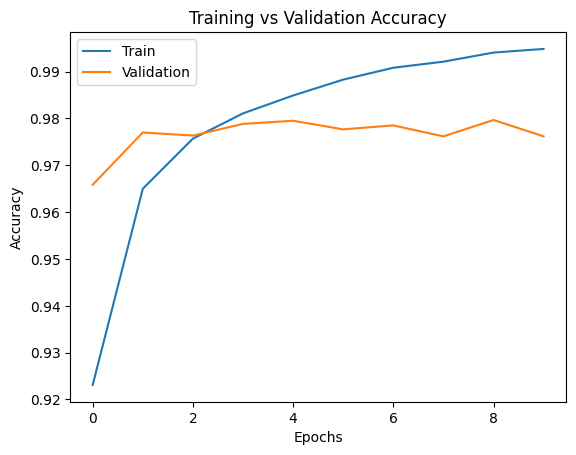

In [12]:
# 1️⃣ Training vs Validation Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

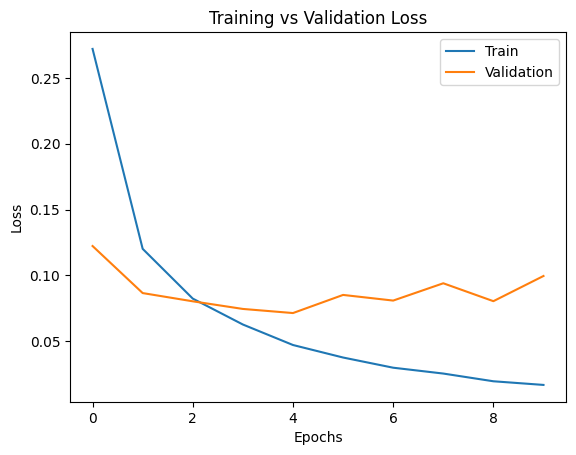

In [13]:
# 2️⃣ Training vs Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


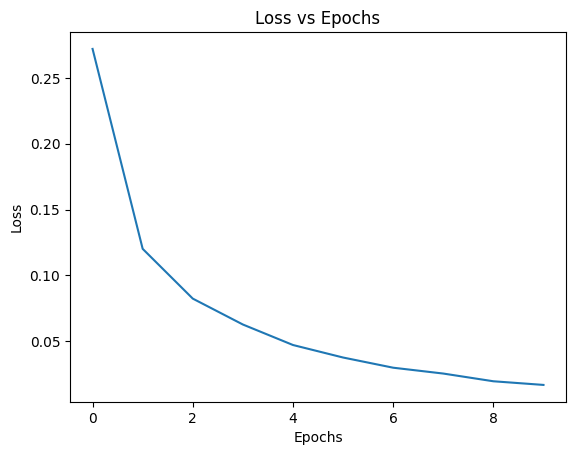

In [14]:
# 3️⃣ Loss vs Epochs (Training Loss only)
plt.plot(history.history['loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()